# Deep Learning-Based Predictions of Phase Ionospheric Scintillations
---
## Authors
__Šimon Mackovjak__<sup>1</sup>, __Viera Krešňáková__<sup>2</sup>, __Peter Butka__<sup>2</sup>, __Matej Varga__<sup>1</sup>, __Samuel Amrich__<sup>1,3</sup>, __Adrián Kundrát__<sup>2</sup>, __Silvia Kostárová__<sup>1,2</sup>

<sup>1</sup>Department of Space Physics, Institute of Experimental Physics, Slovak Academy of Sciences, Košice, Slovakia \
<sup>2</sup>Department of Cybernetics and Artificial Intelligence, Faculty of Electrical Engineering and Informatics, Technical University of Košice, Košice, Slovakia \
<sup>3</sup>Faculty of Mathematics and Physics, Charles University, Prague, Czechia

## Abstract

Ionospheric scintillations are among the most challenging space weather phenomena. The combination of their nondeterministic occurrence and their significant effect on modern technology makes them important risks that need to be mitigated. For this purpose, networks of GNSS receivers were constructed. However, the automatic acquisition of scintillation parameters needs to be followed by automatic data processing to provide timely and actionable information. Therefore, we developed an approach to identify the occurrence of phase ionospheric scintillations in space and time. We explored the capabilities of data-driven models based on deep neural networks to predict parameter σϕ up to one hour ahead. We took a look at a wide range of input parameters and several deep learning techniques. Our best-performing model, based on quantitative and qualitative evaluations, utilizes Long Short-Term Memory (LSTM) networks. The obtained results pave the way for using this approach for the operational service of ionospheric scintillation nowcasting and forecasting for regions covered by GNSS receivers.

---
## Jupyter notebook

In the following, we present the data and Python methods used for analysis described in the article. \
Here is an overview of the Jupyter notebook:

__ENVIROMENT__
* Step 0: Environment set-up

__DATA PREPARATION__
* Step 1: Download data from CHAIN
* Step 2: Create dataset for training models and testing using sliding windows approach

__DEEP LEARNING APPROACH__
* Step 3: Training models

__RESULTS__
* Step 4: Create basic predictions using models
* Step 5: Post-processing for advanced predictions
* Step 6: Evaluation
* Step 7: Visualization
---
## Step 0: Environment set-up

* Import following libraries:

In [1]:
import numpy as np
import pandas as pd
import pickle
import os
import datetime
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
from sklearn.metrics import confusion_matrix

In [2]:
from tensorflow import keras
from keras.layers import Dense, Dropout, Input, LSTM, concatenate, Bidirectional
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from keras.models import Model

## Step 1: Download data from CHAIN
* To see example how to download and process [CHAIN](http://chain.physics.unb.ca/data/gps/ismr/) data manually, use [`data_preparation_from_CHAIN.ipynb`](https://github.com/space-lab-sk/aspis/blob/develop_notebook/data_preparation_from_CHAIN.ipynb).
* Already created datasets for each bin are [here](https://mega.nz/folder/5r5iQIaC#4myXsED61CcgIvdIiYZrhA). The map below shows locations of those bins from May 2013 to December 2021 (the amount of the data, in this case, is represented by the circle size and also by the color of the circle):

<img src="img/chain.png" width="700" height="700">

## Step 2: Create datasets for training and testing models using sliding windows approach

The sliding window approach (figure below) is a technique used to format and process time series data into windows (shown in yellow) and horizons (shown in blue) for use in modeling and forecasting. This approach involves breaking the time series data into multiple windows of fixed length and sliding the window along the time series, one-time step at a time, to create multiple samples of the data. In our case, we processed the time series separately by bins.


<img src="img/sliding-window.png" width="600" height="300">

* If you want to prepare data for training and test manually (custom settings, understanding the process), use [`data_preparation_windows_generator.ipynb`](https://github.com/space-lab-sk/aspis/blob/develop_notebook/data_preparation_windows_generator.ipynb).
* If you want to continue with already prepared ready-to-use datasets, you can download them [here](https://mega.nz/folder/NWdAxaha#VyY9R_i9CcMmEBdqWG77cw).

Data must be generated for each configuration of model inputs, time shift and size of windows settings separately. In the article we present the following models:

| **model**                               |    **label**   | **time shift (`minutes_ahead`)** | **windows (`window_size`)** | **architecture** |
|-----------------------------------------|:--------------:|:-------------------------:|:-------------------------:|:-------------------------:|
| Autoregressive                          | `autoreg`        |             15            |             45            | `autoreg` |
| Autoregressive                          | `autoreg`        |             30            |             45            | `autoreg` |
| Autoregressive                          | `autoreg`        |             45            |             45            | `autoreg` |
| Autoregressive                          | `autoreg`        |             60            |             45            | `autoreg` |
| Base Multivariate Ap                    | `ap_index`       |             15            |             45            | `base_multiNN_hour`  |
| Base Multivariate Asy/H                 | `AsyH`           |             15            |             45            | `base_multiNN_min`   |
| Base Multivariate Bz                    | `BzGSE`          |             15            |             45            | `base_multiNN_min`   |
| Base Multivariate PC                    | `PC`             |             15            |             45            | `base_multiNN_min`   |
| Extended Multivariate Ap, Asy/H, Bz, PC | `all_parameters` |             15            |             45            | `extended_multiNN` |

#### 2.1 Load data
* For the next steps, select the configuration you want to work with (for proper data loading).
> _The example used in this notebook is a **multivariate PC model** for **15-minutes-ahead** forecasts from a **window size of 45 minutes**, which was in our case the best multivariate model. This setting can be changed according to your own requirements._

In [3]:
# CUSTOM SETTINGS

# SET window_size
window_size = 45

# SET how many minutes ahead do we want to predict
minutes_ahead = 15

# SELECT model
model_name = "PC" 
f_data = f"{model_name}/shift-{minutes_ahead}-windows-{window_size}"

* Load train and test data.

In [4]:
X_train_min = np.load(f'data/{f_data}/X_train_min.npy', allow_pickle=True)                      # minute training data (input)
X_train_hour = np.load(f'data/{f_data}/X_train_hour.npy', allow_pickle=True)                    # hourly training data (input)
y_train = np.load(f'data/{f_data}/y_train.npy', allow_pickle=True)                              # output

X_test_min = np.load(f'data/{f_data}/X_test_min.npy', allow_pickle=True)                        # minute testing data (input)
X_test_hour = np.load(f'data/{f_data}/X_test_hour.npy', allow_pickle=True)                      # hourly testing data (input)
y_test = np.load(f'data/{f_data}/y_test.npy', allow_pickle=True)                                # output

test_index_bin = np.load(f'data/{f_data}/test_index_bin.npy', allow_pickle=True)                # bins for testing data
test_index_timestamp = np.load(f'data/{f_data}/test_index_timestamp.npy', allow_pickle=True)    # datetimes for testing data

#### 2.2 Select data for training (according to `model_name`)

In [5]:
# minutes data of Phi60_Sig1 (intensity of phase ionospheric scintillaction)
X_Phi60_Sig1_model = X_train_min["Phi60_Sig1"]   

# additional parameter for multivariate models 
if model_name == "ap_index":
    X_param_model = X_train_hour["ap_index"]
elif "autoreg" not in model_name:
    X_param_model = X_train_min[model_name]
elif model_name == "all_parameters":
    X_ap_index = X_train_hour["ap_index"]
    X_PC = X_train_min["PC"]
    X_AsyH = X_train_min["AsyH"]
    X_BzGSE = X_train_min["BzGSE"]

## Step 3: Training models
#### 3.1 Create model architecture

__Autoregressive__ time series forecasting is a method of using past values of a time series to model and make predictions about future values. In __multivariate__ or multi-input forecasting, multiple variables are used as input to predict a single output variable. This type of forecasting is commonly used in problems where multiple variables are believed to have an impact on the outcome. We experimented with autoregressive and multivariate models.

For time series forecasting models, deep learning often refers to the Recurrent Neural Networks (RNNs) and Long Short-Term Memory (LSTM) networks, to model and make predictions about time series data. These techniques are often used to capture non-linear dependencies within time series. Here are examples of autoregressive model architecture and base multivariate model architecture containing Bidirectional LSTM. 

<img src="img/architectures.png" width="1000" height="300">

* Create architecture of neural network according to input data. 

In [6]:
# acrhitecture "autoreg"

if model_name == "autoreg":
    
    inputs_Phi60_Sig1 = Input(shape=(X_Phi60_Sig1_model.shape[1],1))
    a = Bidirectional(LSTM(128, dropout=0.1,recurrent_dropout=0.1))(inputs_Phi60_Sig1)
    a = Dense(64, activation='relu')(a)
    a = Dropout(0.2)(a)
    a = Dense(64, activation='relu')(a)
    a = Dense(32, activation='relu')(a)
    output = Dense(1, activation='linear')(a)

# -----------------------------------

# architecture "extended_multiNN"

elif model_name == "all_parameters":
    
    # Define 5 sets of inputs
    input_Phi60_Sig1 = Input(shape=(X_Phi60_Sig1_model.shape[1], 1))
    input_PC = Input(shape=(X_PC.shape[1], 1))
    input_AsyH = Input(shape=(X_AsyH.shape[1], 1))
    input_BzGSE = Input(shape=(X_BzGSE.shape[1], 1))
    input_ap = Input(shape=(X_ap.shape[1], 1))

    a = Bidirectional(LSTM(64, dropout=0.1, recurrent_dropout=0.1))(input_Phi60_Sig1)
    a = Dense(32, activation='relu')(a)
    b = Bidirectional(LSTM(64, dropout=0.1, recurrent_dropout=0.1))(input_PC)
    b = Dense(32, activation='relu')(b)
    c = Bidirectional(LSTM(64, dropout=0.1, recurrent_dropout=0.1))(input_AsyH)
    c = Dense(32, activation='relu')(c)
    d = Bidirectional(LSTM(64, dropout=0.1, recurrent_dropout=0.1))(input_BzGSE)
    d = Dense(32, activation='relu')(d)
    e = Bidirectional(LSTM(64, dropout=0.1, recurrent_dropout=0.1))(input_ap)
    e = Dense(32, activation='relu')(e)

    # Combine the output of the 5 branches
    x = concatenate([a, b, c, d, e])
    x = Dense(32, activation='relu')(x)
    x = Dropout(0.2)(x)  
    x = Dense(32, activation='relu')(x)

    # Apply a final Dense layer for regression prediction
    output = Dense(1, activation='linear')(x)
    
# -----------------------------------
    
# architure "base_multiNN_min" & "base_multiNN_hour"

# the difference is number of neurons on additional branch (45 neurons for "base_multiNN_min", 1 neuron for "base_multiNN_hour")

else:
    
    # Define 2 sets of inputs
    input_param = Input(shape=(X_param_model.shape[1], 1))
    input_Phi60_Sig1 = Input(shape=(X_Phi60_Sig1_model.shape[1], 1))
    
    # First branch
    a = Bidirectional(LSTM(64, dropout=0.1, recurrent_dropout=0.1))(input_Phi60_Sig1)
    a = Dense(32, activation='relu')(a)
    
    # Second branch
    b = Bidirectional(LSTM(64, dropout=0.1, recurrent_dropout=0.1))(input_param)
    b = Dense(32, activation='relu')(b)
    
    # Combine the output of the 2 branches
    x = concatenate([a, b])
    x = Dense(32, activation='relu')(x)
    x = Dropout(0.2)(x)
    x = Dense(32, activation='relu')(x)
    
    # Apply a final Dense layer for regression prediction
    output = Dense(1, activation='linear')(x)

2024-09-06 07:53:01.567117: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1532] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6675 MB memory:  -> device: 0, name: Quadro RTX 4000, pci bus id: 0000:8b:00.0, compute capability: 7.5


* Create and compile the model

In [7]:
if model_name == "autoreg":
    classifier = Model(inputs=[input_Phi60_Sig1], outputs=output)
elif model_name == "all_parameters":
    classifier = Model(inputs=[input_ap, input_BzGSE, input_AsyH, input_PC, input_Phi60_Sig1], outputs=output)
else:
    classifier = Model(inputs=[input_param, input_Phi60_Sig1], outputs=output)

classifier.compile(loss='mse', optimizer="adam", metrics=['mae'])
print(classifier.summary())

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_2 (InputLayer)           [(None, 45, 1)]      0           []                               
                                                                                                  
 input_1 (InputLayer)           [(None, 45, 1)]      0           []                               
                                                                                                  
 bidirectional (Bidirectional)  (None, 128)          33792       ['input_2[0][0]']                
                                                                                                  
 bidirectional_1 (Bidirectional  (None, 128)         33792       ['input_1[0][0]']                
 )                                                                                            

#### 3.2 Training
* If you want train model manually, continue with the code below. If you want to skip this step and use already trained model, go to next section.

In [ ]:
# callbacks
os.makedirs("model/"+f_data, exist_ok=True)
saved_model = "/epoch-{epoch:02d}-mae-{val_mae:.4f}.hdf5"
checkpoint = ModelCheckpoint("model/"+f_data+saved_model, monitor='val_mae', verbose=1, save_freq="epoch")
callbacks_list = [checkpoint]

# training
if model_name == "autoreg":
    x_for_train = [X_Phi60_Sig1_model]
elif model_name == "all_parameters":
    x_for_train = [X_ap_index, X_BzGSE, X_AsyH, X_PC, X_Phi60_Sig1_model]
else:
    x_for_train = [X_param_model, X_Phi60_Sig1_model]

history = classifier.fit(
    x = x_for_train,
    y = y_train,
    validation_split = 0.1,
    epochs = 10,
    verbose = 1,
    callbacks = callbacks_list,
    shuffle = True)

## Step 4: Basic Predictions
#### 4.1 Load model for prediction
* If the previous step (training) was skipped, load model from [`models`]() (this folder contains the best models for every scenario). 

In [8]:
model = keras.models.load_model(f"model/{model_name}-shift-{minutes_ahead}-windows-{window_size}.hdf5", compile=False)

* If you trained model by yourself and want to use model from specific epoch, load model by:

In [ ]:
# epoch = ""
# mae = ""
# model = keras.models.load_model(f"model/{model_name}/shift-{minutes_ahead}-windows-{window_size}/epoch-{epoch}-mae-{mae}.hdf5", compile=False)

#### 4.2 Predict _y_ 

In [ ]:
Phi60_Sig1_test = X_test_min["Phi60_Sig1"]

if model_name == "ap_index":
    param_test = X_test_hour["ap_index"]
    y_pred = model.predict([param_test, Phi60_Sig1_test])
elif model_name == "all_parameters":
    ap_index_test = X_test_hour["ap_index"]
    PC_test = X_test_min["PC"]
    AsyH_test = X_test_min["AsyH"]
    BzGSE_test = X_test_min["BzGSE"]
    y_pred = model.predict([ap_index_test, BzGSE_test, AsyH_test, PC_test, Phi60_Sig1_test])
elif "autoreg" not in model_name:
    param_test = X_test_min[model_name]
    y_pred = model.predict([param_test, Phi60_Sig1_test])
else:
    y_pred = model.predict(Phi60_Sig1_test, verbose = 1)

* If prediction takes too much time, you can use predicted data from [`predictions`]().

In [9]:
y_pred = np.load(f"predictions/y_pred-{model_name}-shift-{minutes_ahead}-windows-{window_size}.npy")

## Step 5: Post-processing
* For post-processing we use coefficient of variance (CoV), which is a statistical measure of the dispersion of data points around the mean. It is calculated as the ratio of the standard deviation to the mean.
#### 5.1 CoV calculation
* First, we need to prepare data for CoV calculation:

In [10]:
# SET the size of the ratio of the subset to the entire dataset for testing. If you want to work with the entire dataset, keep size = 1.
size = 1

y_test = y_test.flatten()
y_pred = y_pred.flatten()
test_index_bin = test_index_bin.flatten()
test_index_timestamp = test_index_timestamp.flatten()

# create dataframe and fill it with values
param_df = pd.DataFrame(data={f"{model_name}_test": y_test[:int(len(y_test)/size)], f"{model_name}_pred": y_pred[:int(len(y_pred)/size)], f"{model_name}_bin":test_index_bin[:int(len(y_test)/size)], f"{model_name}_time":test_index_timestamp[:int(len(y_test)/size)]})
param_df[f"{model_name}_bin"] = param_df[f"{model_name}_bin"].str[:5]
param_df["index_time_bin"] = param_df[f"{model_name}_time"]+" "+param_df[f"{model_name}_bin"] # unique combination of date and bin
param_df[f"{model_name}_time"] = pd.to_datetime(param_df[f"{model_name}_time"])
param_df = param_df.set_index("index_time_bin")
param_df

,PC_test,PC_pred,PC_bin,PC_time
index_time_bin,,,,
2019-01-01 01:27:00 14117,0.031,0.064558,14117,2019-01-01 01:27:00
2019-01-01 01:28:00 14117,0.029,0.064681,14117,2019-01-01 01:28:00
2019-01-01 01:29:00 14117,0.030,0.063228,14117,2019-01-01 01:29:00
2019-01-01 01:30:00 14117,0.033,0.062721,14117,2019-01-01 01:30:00
2019-01-01 01:31:00 14117,0.024,0.064875,14117,2019-01-01 01:31:00
...,...,...,...,...
2019-10-06 21:48:00 13927,0.029,0.062144,13927,2019-10-06 21:48:00
2019-10-06 21:49:00 13927,0.033,0.061490,13927,2019-10-06 21:49:00
2019-10-06 21:50:00 13927,0.031,0.061066,13927,2019-10-06 21:50:00


* Here is mean value we later used in calculation:

In [11]:
global_mean = param_df[f"{model_name}_test"].mean()
global_mean

0.035651657105404654

* Select time windows around each _y_ value. The size of the window is defined by `window_cov` (before and after _y_), which means that the default window size used to calculate CoV in this notebook is 45 minutes. We used this value because we also worked with it when generating time windows, and it also turned out that the CoV values from the 45-minute window differ significantly between scintillation and non-scintillation cases. 

In [ ]:
# SET window_cov

window_cov = 22

n = len(param_df)
pred_std = []
test_std = []

for i in range(n):
    subset = param_df[max(0,i-window_cov):min(i+window_cov+1, n)]
    subset = subset[subset[f"{model_name}_bin"] == param_df[f"{model_name}_bin"][i]]
    subset = subset[subset[f"{model_name}_time"] <= param_df[f"{model_name}_time"][i] + datetime.timedelta(minutes=window_cov)]
    subset = subset[subset[f"{model_name}_time"] >= param_df[f"{model_name}_time"][i] - datetime.timedelta(minutes=window_cov)]
    
    # calculate std
    pred_std.append(subset[f"{model_name}_pred"].std())
    test_std.append(subset[f"{model_name}_test"].std())
    
param_df[f"{model_name}_std_pred"] = pred_std
param_df[f"{model_name}_std_test"] = test_std

# calculate CoV
param_df[f"{model_name}_cov_pred"] = param_df[f"{model_name}_std_pred"]/global_mean
param_df[f"{model_name}_cov_test"] = param_df[f"{model_name}_std_test"]/global_mean

* If the post-processing takes too long, you can download data [here](https://mega.nz/folder/Nb1SGDzA#ILZCNLN0epyc9HIgfeLWVA) and load them as:

In [12]:
param_df = pd.read_csv(f"post_processing/{model_name}_predictions_on_test-data_with_time-bin_std-cov_full-test.csv")

Now we have CoV for true test values and CoV for predicted values. Let's plot their behavior.
#### 5.2 Comparison between true values, predicted values and CoV values
* Here are functions and settings for plot:

In [13]:
# plot settings
myFmt = mdates.DateFormatter('%H:%M \n%d %b ')
size_of_marker = 2.5
size_of_marker2 = 0.5

def add_text_plot(lim):
    plt.ylabel(r'$\sigma_\phi [rad]$', fontsize=12)
    plt.axhline(0.1, color='silver', linewidth=2)
    plt.grid(True, linewidth=0.3)
    plt.ylim(0, lim)
    plt.gca().xaxis.set_major_formatter(myFmt)

* You can select any bin you want to plot. For better clarity, we always display data from only one bin at a time.:

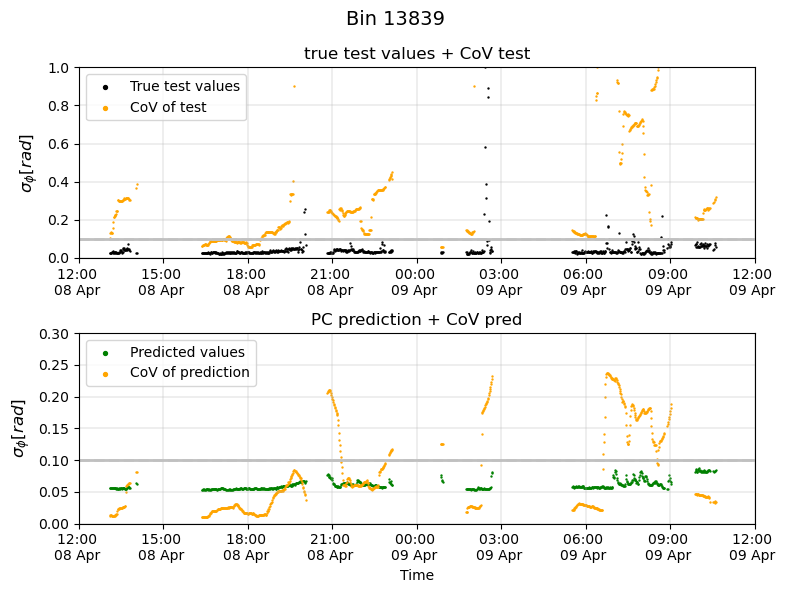

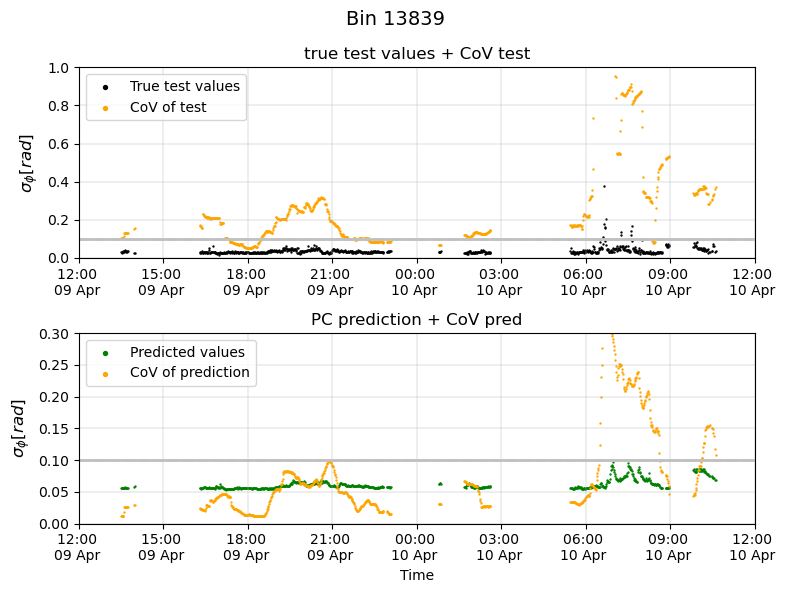

In [14]:
# SET bin you want to plot
bin_used = 13839

scinti_df = param_df[param_df[f"{model_name}_bin"] == bin_used]
scinti_df = scinti_df.set_index(pd.to_datetime(scinti_df[f"{model_name}_time"]))

plt.rcParams["figure.figsize"] = (8,6)

# SET start time for plot
start_time = '2019-04-08 12:00:00' 

# SET how many weeks you want to plot
n_of_weeks = 2

for i in range(0, n_of_weeks): # plot per week
    fig, ax = plt.subplots(2,1)
    plt.setp(ax, xlim=(pd.Timestamp(start_time)+datetime.timedelta(days=i*1), pd.Timestamp(start_time)+datetime.timedelta(days=i*1+1)))
    plt.suptitle(f'Bin {bin_used}', fontsize=14)

    plt.subplot(2, 1, 1).set_title("true test values + CoV test")
    scatter1=plt.scatter(scinti_df.index, scinti_df[f"{model_name}_test"], s=size_of_marker2, c="black", label="True test values")
    scatter2=plt.scatter(scinti_df.index, scinti_df[f"{model_name}_cov_test"], s=size_of_marker2, c="orange", label="CoV of test")
    plt.legend(markerscale=4)
    plt.axhline(0.1, color='lightgray', linewidth=2, linestyle="--")
    add_text_plot(1)
    
    plt.subplot(2, 1, 2).set_title(f"{model_name} prediction + CoV pred", fontsize=12)
    scatter3=plt.scatter(scinti_df.index, scinti_df[f"{model_name}_pred"], s=size_of_marker2, c="green", label="Predicted values")
    scatter4=plt.scatter(scinti_df.index, scinti_df[f"{model_name}_cov_pred"], s=size_of_marker2, c="orange",  label="CoV of prediction")
    plt.legend(markerscale=4)
    plt.axhline(0.1, color='lightgray', linewidth=2, linestyle="--")
    add_text_plot(0.3)
    
    plt.xlabel("Time")
    
    plt.subplots_adjust(left=0.1,
                    bottom=0.1,
                    right=0.9,
                    top=0.9,
                    wspace=0.4,
                    hspace=0.5)
    plt.tight_layout()
    #plt.savefig(".png")
    
    plt.show()

Notes:
* First row - test values (black) and CoV of test values (orange)
* Second row - predicted values (green) and CoV of predicted values (orange)

From graphs we can estimate threshold values for scintillation detection. 

## Step 6: Evaluation

* Here is function to calculate metrics:

In [15]:
def metrics(true, pred):
    #true = true.dropna()
    #pred = pred.dropna()
    
    cm = confusion_matrix(true, pred, labels=[0,1])
    #print(cm)
    tn = cm[0][0]
    fp = cm[0][1]
    fn = cm[1][0]
    tp = cm[1][1]

    precision = float(tp/(tp+fp)) 
    recall = float(tp/(tp+fn))  
    f1 = float((2*precision*recall)/(precision+recall))
    tss = float((tp/(tp+fn)) - (fp/(fp+tn)))
    
    return precision, recall, f1, tss, tn, fp, fn, tp

* Here are settings of CoV threshold values for ionospheric scintillation detection. For test data, we always use a CoV threshold value of 0.5, as it seems to be the option that covers the most scintillation points while excluding a large number of non-scintillation points.

In [16]:
# settings - CoV


# TRUE data

var_coef_true_values = [0.5] # if CoV > 0.5 then scintillation; else not-scintillation


# PREDICTED data

# for autoreg model
if "autoreg" in model_name:
    var_coef_pred_values = np.arange(0.001,0.0201, 0.0001) 
    x_axis = np.arange(0.000,0.0201,0.002)
    
# for multiNN model
else:
    var_coef_pred_values = np.arange(0.01,0.201, 0.001) 
    x_axis = np.arange(0.00,0.201, 0.02)

* Create evaluation for every combination (CoV test values, CoV predicted values) and show results:

In [17]:
results = pd.DataFrame(columns=["cov_true", "cov_test", "precision", "recall", "f1", "tss", "tn", "fp", "fn", "tp"])
for vc_true in var_coef_true_values:
    param_df["True"] = np.where(param_df[f"{model_name}_cov_test"] < vc_true, 0, 1)
    for vc_pred in var_coef_pred_values:
        param_df["Pred"] = np.where(param_df[f"{model_name}_cov_pred"] < vc_pred, 0, 1)
        
        true_col = 'True'
        pred_col = 'Pred'
        
        res = metrics(param_df[true_col], param_df[pred_col])
        results.loc[len(results)] = [vc_true, vc_pred, res[0], res[1], res[2], res[3], res[4], res[5], res[6], res[7]]
results

,cov_true,cov_test,precision,recall,f1,tss,tn,fp,fn,tp
0,0.5,0.010,0.118198,0.996232,0.211324,0.026234,105656.0,3415907.0,1732.0,457874.0
1,0.5,0.011,0.119553,0.994630,0.213449,0.038636,154969.0,3366594.0,2468.0,457138.0
2,0.5,0.012,0.121341,0.992761,0.216250,0.054533,217535.0,3304028.0,3327.0,456279.0
3,0.5,0.013,0.123514,0.990781,0.219647,0.073177,290162.0,3231401.0,4237.0,455369.0
4,0.5,0.014,0.126099,0.988379,0.223663,0.094409,373391.0,3148172.0,5341.0,454265.0
...,...,...,...,...,...,...,...,...,...,...
186,0.5,0.196,0.760968,0.423608,0.544249,0.406242,3460407.0,61156.0,264913.0,194693.0
187,0.5,0.197,0.762404,0.420032,0.541651,0.402948,3461401.0,60162.0,266557.0,193049.0
188,0.5,0.198,0.763712,0.416746,0.539238,0.399918,3462302.0,59261.0,268067.0,191539.0
189,0.5,0.199,0.765436,0.413606,0.537028,0.397064,3463309.0,58254.0,269510.0,190096.0


* We can also plot results:

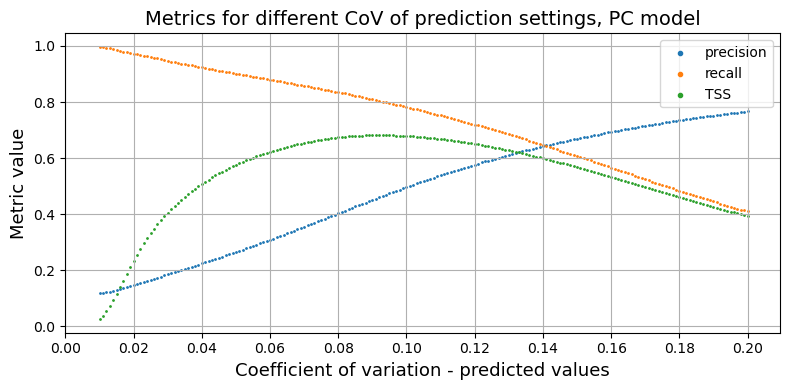

In [18]:
plt.figure(figsize=(8,4))
plt.scatter(results["cov_test"], results["precision"],s=1,label="precision")
plt.scatter(results["cov_test"], results["recall"],s=1,label="recall")
plt.scatter(results["cov_test"], results["tss"],s=1,label="TSS")
plt.xlabel("Coefficient of variation - predicted values", fontsize=13)
plt.ylabel("Metric value", fontsize=13)
plt.title(f"Metrics for different CoV of prediction settings, {model_name} model", fontsize=14)
plt.legend(markerscale=3)
plt.grid()
plt.tight_layout()
plt.xticks(x_axis, size=10)
plt.show()

## Step 7: Visualization
Final step is visualization of predictions. This means that we want to show which values are detected as scintillation and not-scintillation according to our models prediction with post-processing. We also want to show which values are detected correctly (TP, TN) and where are mistakes (FP, FN). 
* Some functions for plot:

In [19]:
def create_conditions(true, pred):
    return [(true == 1) & (pred == 1),
     (true == 0) & (pred == 0),
     (true == 1) & (pred == 0),
     (true == 0) & (pred == 1)]

# create legend for TP, TN, FP and FN
def add_legend_classification():
    legend_elements = [Line2D([0], [0], marker='o', color='w', label='TN', markerfacecolor="#1f77b4", markersize=6),
                       Line2D([0], [0], marker='o', color='w', label='FP', markerfacecolor='#ff7f0e', markersize=6),
                       Line2D([0], [0], marker='o', color='w', label='TP', markerfacecolor='#2ca02c', markersize=6),
                       Line2D([0], [0], marker='o', color='w', label='FN', markerfacecolor='#d62728', markersize=6)]
    plt.legend(handles=legend_elements, loc='upper right')
    
values = [3, 1, 4, 2]

#### 7.1 Comparison of different settings of CoV (for one model)
* Settings for different threshold values of CoV:

In [20]:
bin_used = 13839
CoV_pred_set = [0.01, 0.02, 0.05, 0.1]
CoV_true_set = [0.5, 0.5, 0.5, 0.5]

l=list(map(list, zip(*[range(len(CoV_pred_set)), CoV_pred_set, CoV_true_set]))) 
l

[[0, 0.01, 0.5], [1, 0.02, 0.5], [2, 0.05, 0.5], [3, 0.1, 0.5]]

* Binary classification:

In [21]:
visual1_df = param_df[param_df[f"{model_name}_bin"] == bin_used].copy()

for x, pred, true in l:
    visual1_df[f"True_set_{x}"] = np.where(visual1_df[f"{model_name}_cov_test"] < true, 0, 1)
    visual1_df[f"Pred_set_{x}"] = np.where(visual1_df[f"{model_name}_cov_pred"] < pred, 0, 1)
    conditions = create_conditions(visual1_df[f"True_set_{x}"], visual1_df[f"Pred_set_{x}"])
    visual1_df[f'e_cm_color_{x}'] = np.select(conditions, values)

* Add persistence prediction:

In [22]:
visual1_df['persistence_shift_time'] = pd.to_datetime(visual1_df[f"{model_name}_time"]) - datetime.timedelta(minutes=minutes_ahead)
visual1_df['persistence_shift_time'] = visual1_df['persistence_shift_time'].astype(str)
visual1_df['persistence_shift_time'] = visual1_df['persistence_shift_time']+" "+visual1_df[f'{model_name}_bin'].astype(str)

mapping_true = dict(visual1_df[['index_time_bin', f"{model_name}_test"]].values)
visual1_df['persistence'] = visual1_df["persistence_shift_time"].map(mapping_true)

visual1_df["persistence_true"]=np.where(visual1_df[f"{model_name}_test"] >= 0.1, 1, 0)
visual1_df["persistence_pred"]=np.where(visual1_df["persistence"] >= 0.1, 1, 0)

conditions_P = create_conditions(visual1_df['persistence_true'], visual1_df['persistence_pred'])
visual1_df['eP_cm_color'] = np.select(conditions_P, values)

visual1_df.head()

,index_time_bin,PC_test,PC_pred,PC_bin,PC_time,PC_std_pred,PC_std_test,PC_cov_pred,PC_cov_test,True,...,Pred_set_2,e_cm_color_2,True_set_3,Pred_set_3,e_cm_color_3,persistence_shift_time,persistence,persistence_true,persistence_pred,eP_cm_color
3643973,2019-01-01 00:59:00 13839,0.028,0.055311,13839,2019-01-01 00:59:00,0.000348,0.006885,0.009762,0.193121,0,...,0,1,0,0,1,2019-01-01 00:44:00 13839,NaN,0,0,1
3643974,2019-01-01 01:00:00 13839,0.027,0.055258,13839,2019-01-01 01:00:00,0.000572,0.007691,0.016049,0.215730,0,...,0,1,0,0,1,2019-01-01 00:45:00 13839,NaN,0,0,1
3643975,2019-01-01 01:01:00 13839,0.024,0.055594,13839,2019-01-01 01:01:00,0.000582,0.009603,0.016327,0.269346,0,...,0,1,0,0,1,2019-01-01 00:46:00 13839,NaN,0,0,1
3643976,2019-01-01 01:02:00 13839,0.028,0.055044,13839,2019-01-01 01:02:00,0.000603,0.009387,0.016920,0.263298,0,...,0,1,0,0,1,2019-01-01 00:47:00 13839,NaN,0,0,1
3643977,2019-01-01 01:03:00 13839,0.028,0.054629,13839,2019-01-01 01:03:00,0.000787,0.009391,0.022070,0.263409,0,...,0,1,0,0,1,2019-01-01 00:48:00 13839,NaN,0,0,1


* Plotting predictions by week:

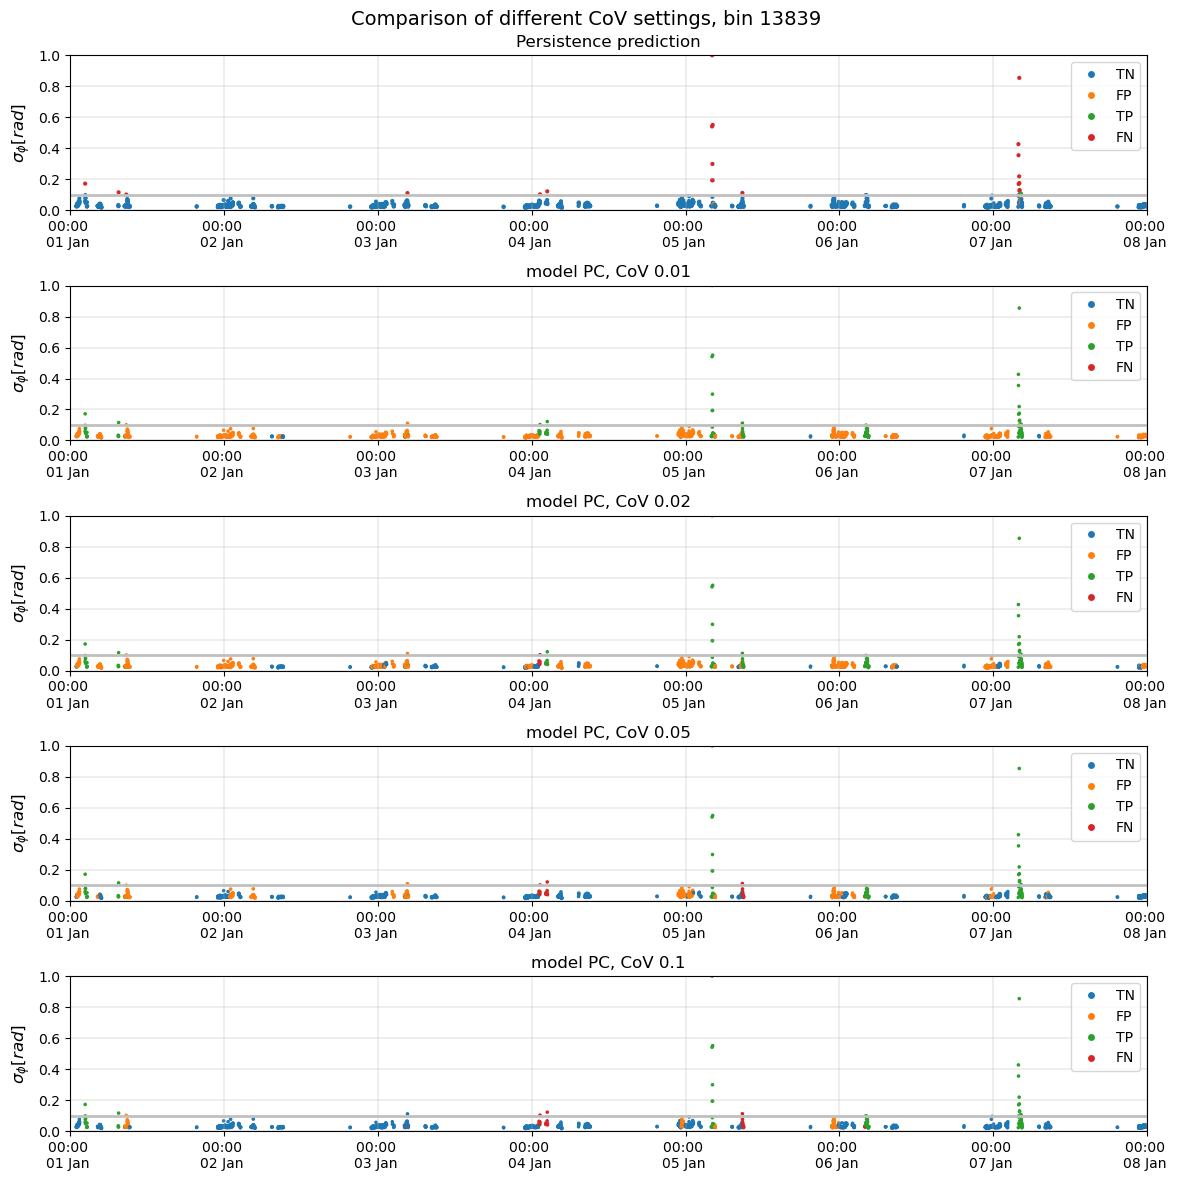

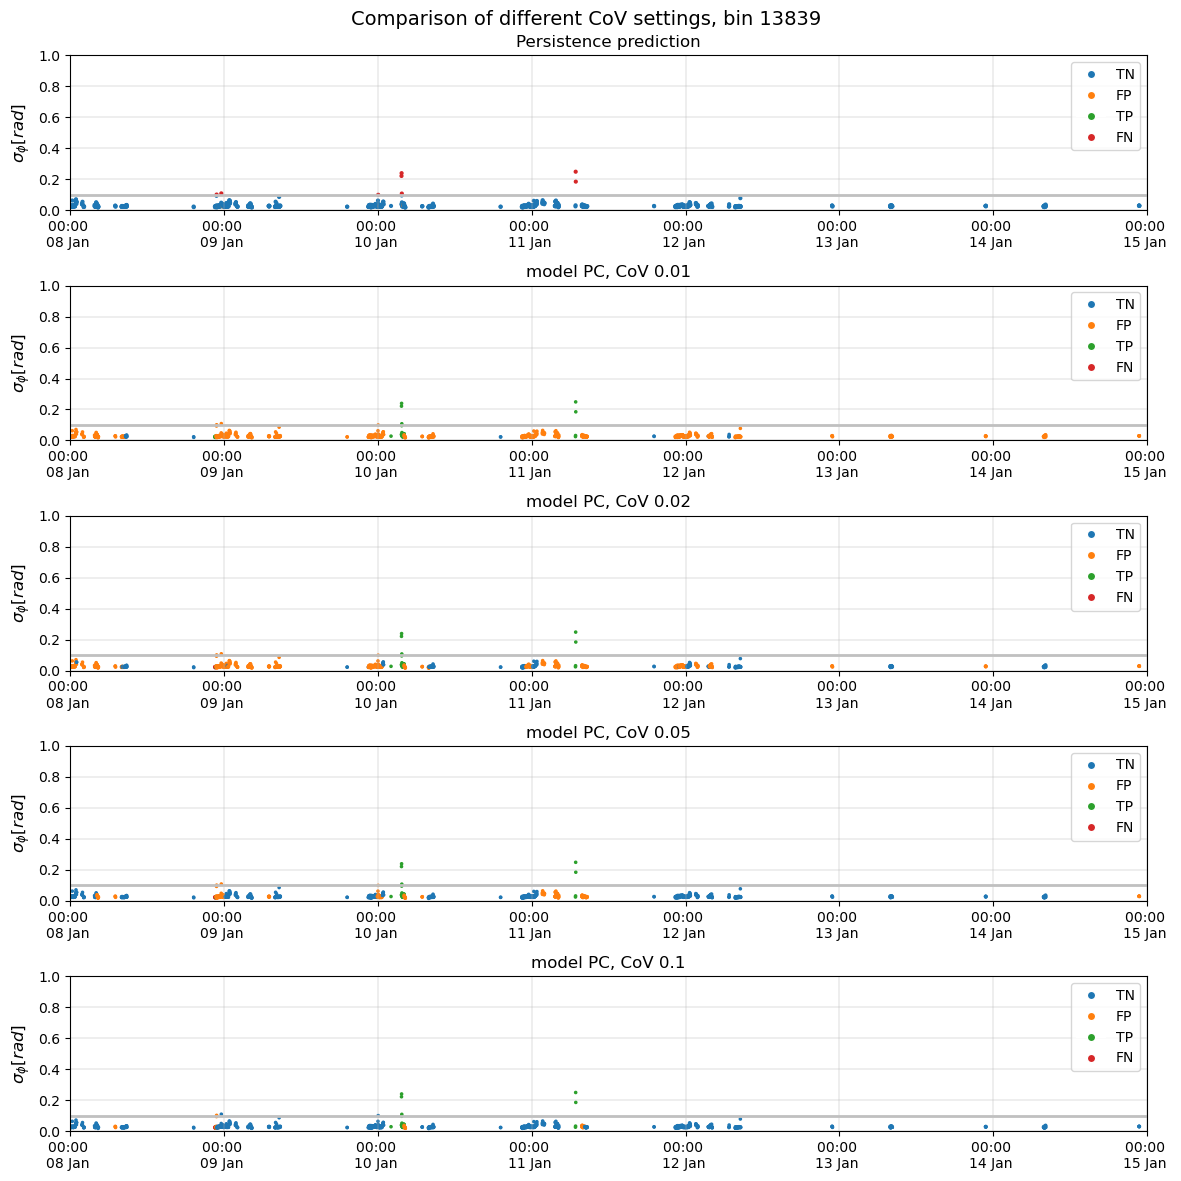

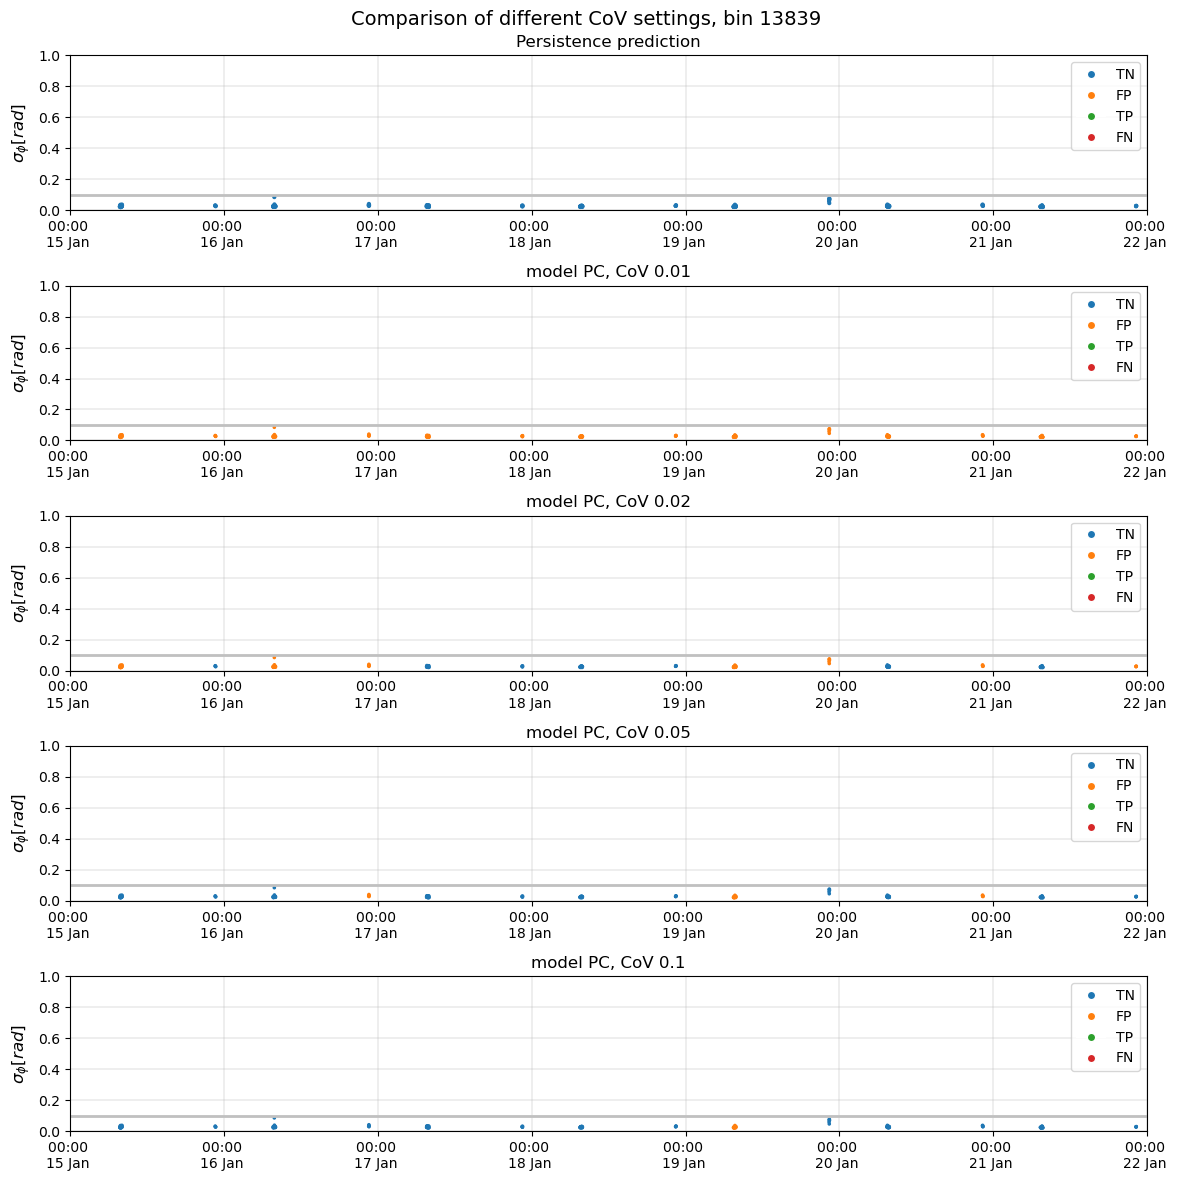

In [23]:
# SETTINGS
start_time = '2019-01-01 00:00:00'   # start time for plot
weeks = 2                            # how many weeks to plot

plt.rcParams["figure.figsize"] = (12,12)
n = len(CoV_pred_set)

for i in range(0, weeks+1):  
    fig, ax = plt.subplots(n+1, 1)
    plt.setp(ax, xlim=(pd.Timestamp(start_time)+datetime.timedelta(days=i*7), pd.Timestamp(start_time)+datetime.timedelta(days=i*7+7)))
    plt.suptitle(f'Comparison of different CoV settings, bin {bin_used}', fontsize=14)
    
    plt.subplot(n+1, 1, 1).set_title("Persistence prediction")
    scatter = plt.scatter(visual1_df[f"{model_name}_time"], visual1_df[f"{model_name}_test"], s=4, c=visual1_df['eP_cm_color'], cmap="tab10", vmin=1, vmax=10)
    add_text_plot(1)
    add_legend_classification()
    
    ix = 1
    for x, pred, true in l:
        ix = ix+1
        plt.subplot(n+1, 1, ix).set_title(f"model {model_name}, CoV {pred}", fontsize=12)
        scatter=plt.scatter(visual1_df[f"{model_name}_time"], visual1_df[f"{model_name}_test"], s=size_of_marker, c=visual1_df[f'e_cm_color_{x}'], cmap="tab10", vmin=1, vmax=10)
        add_text_plot(1)
        add_legend_classification()

    plt.subplots_adjust(left=0.1,
                    bottom=0.1,
                    right=0.9,
                    top=0.9,
                    wspace=0.4,
                    hspace=0.5)
    
    plt.tight_layout()
    #plt.savefig(f"img{ix}.png")
    plt.show()

* This is visualization only for one model. If we want compare different models (different `model_name`), we need predictions and their CoV calculations. For this purpose you can create them manually using steps above, or you can download them [here](https://mega.nz/folder/Nb1SGDzA#ILZCNLN0epyc9HIgfeLWVA). 

#### 7.2 Comparison of different (multiple) models

* Data loading. Select models and bin you want to plot. Set thresholds for CoV evaluation.

In [24]:
visual2_models = ["autoreg15", "PC", "all_parameters"]
bin_used = 13839
CoV_pred_set = [0.01, 0.1, 0.05]
CoV_true_set = [0.5, 0.5, 0.5]

l=list(map(list, zip(*[visual2_models, CoV_pred_set, CoV_true_set]))) 
l

[['autoreg15', 0.01, 0.5], ['PC', 0.1, 0.5], ['all_parameters', 0.05, 0.5]]

* Data loading and binary classification:

In [25]:
visual2_datasets = []
for m, pred, true in l:
    tmp = pd.read_csv(f"../post_processing/{m}_predictions_on_test-data_with_time-bin_std-cov_full-test.csv").set_index("index_time_bin")
    tmp = tmp[tmp[f"{m}_bin"] == bin_used]
    tmp[f"True_set_{m}"] = np.where(tmp[f"{m}_cov_test"] < true, 0, 1)
    tmp[f"Pred_set_{m}"] = np.where(tmp[f"{m}_cov_pred"] < pred, 0, 1)
    conditions = create_conditions(tmp[f"True_set_{m}"], tmp[f"Pred_set_{m}"])
    tmp[f'e_cm_color_{m}'] = np.select(conditions, values)
    visual2_datasets.append(tmp)

* Intersection:

In [26]:
visual2_df = pd.concat(visual2_datasets, axis=1)
visual2_df = visual2_df.dropna()
visual2_df.head()

,autoreg15_test,autoreg15_pred,autoreg15_bin,autoreg15_time,autoreg15_std_pred,autoreg15_std_test,autoreg15_cov_pred,autoreg15_cov_test,autoreg15_count_for_cov,True_set_autoreg15,...,all_parameters_pred,all_parameters_bin,all_parameters_time,all_parameters_std_pred,all_parameters_std_test,all_parameters_cov_pred,all_parameters_cov_test,True_set_all_parameters,Pred_set_all_parameters,e_cm_color_all_parameters
index_time_bin,,,,,,,,,,,,,,,,,,,,,
2019-01-01 01:27:00 13839,0.058,0.082562,13839,2019-01-01 01:27:00,0.000149,0.012700,0.004176,0.356295,20,0,...,0.038293,13839.0,2019-01-01 01:27:00,0.000257,0.012369,0.007153,0.344041,0.0,0.0,1.0
2019-01-01 01:28:00 13839,0.076,0.082518,13839,2019-01-01 01:28:00,0.000149,0.012591,0.004187,0.353247,19,0,...,0.038732,13839.0,2019-01-01 01:28:00,0.000257,0.012369,0.007153,0.344041,0.0,0.0,1.0
2019-01-01 01:29:00 13839,0.046,0.082422,13839,2019-01-01 01:29:00,0.000152,0.012936,0.004266,0.362924,18,0,...,0.038730,13839.0,2019-01-01 01:29:00,0.000257,0.012369,0.007153,0.344041,0.0,0.0,1.0
2019-01-01 01:30:00 13839,0.058,0.082270,13839,2019-01-01 01:30:00,0.000150,0.012905,0.004198,0.362034,17,0,...,0.038278,13839.0,2019-01-01 01:30:00,0.000257,0.012369,0.007153,0.344041,0.0,0.0,1.0
2019-01-01 02:21:00 13839,0.058,0.082690,13839,2019-01-01 02:21:00,0.000858,0.044223,0.024071,1.240657,11,1,...,0.050252,13839.0,2019-01-01 02:21:00,0.004453,0.044223,0.123869,1.230020,1.0,1.0,3.0


* Plotting predictions by week:

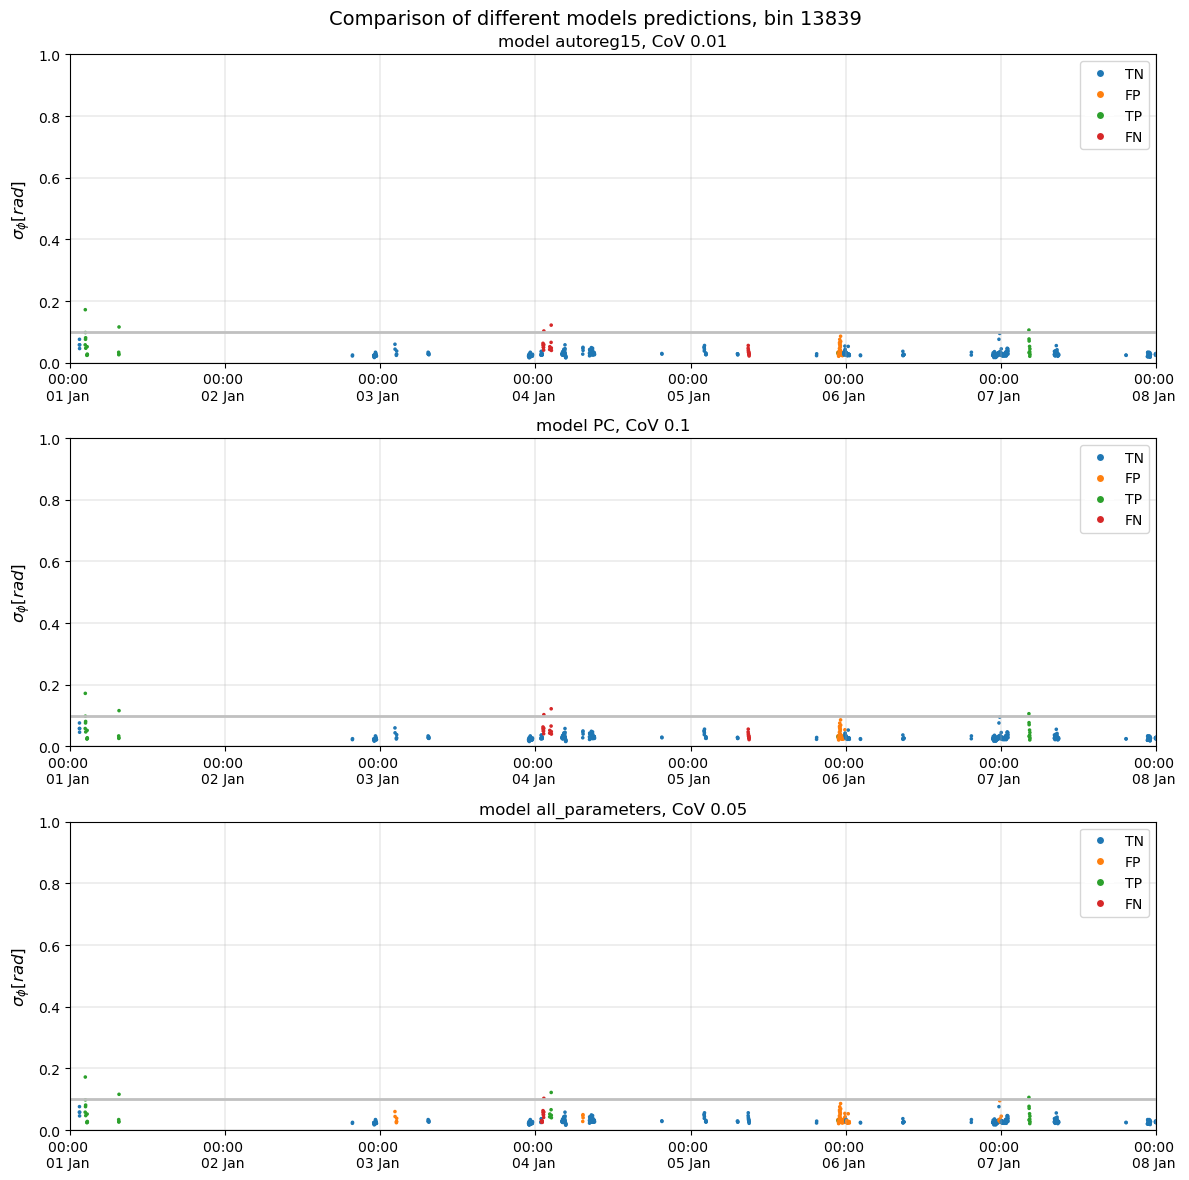

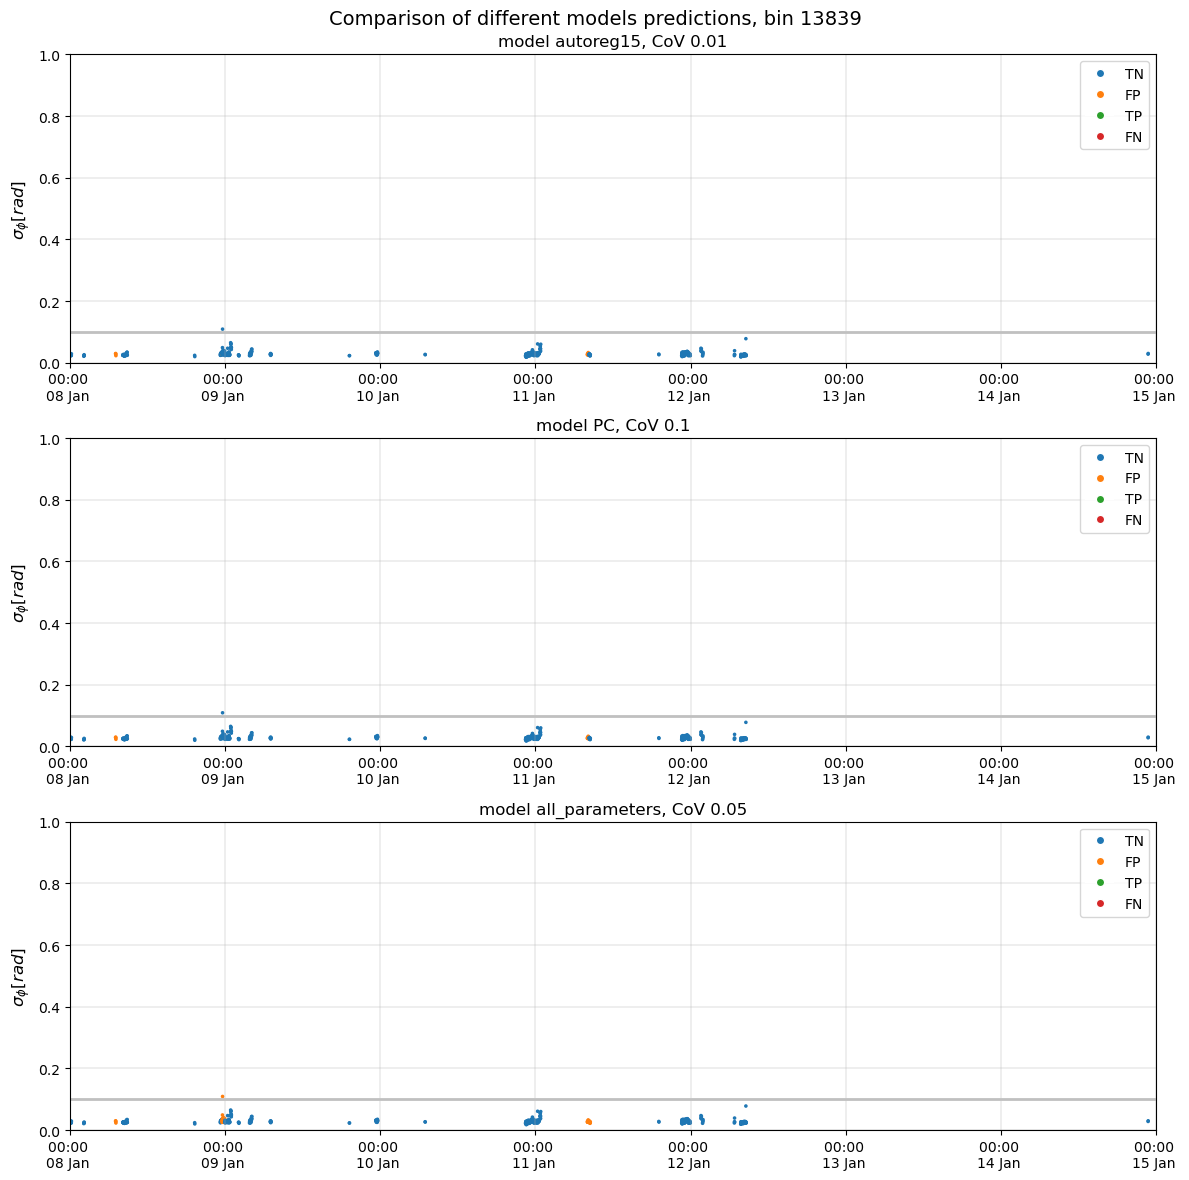

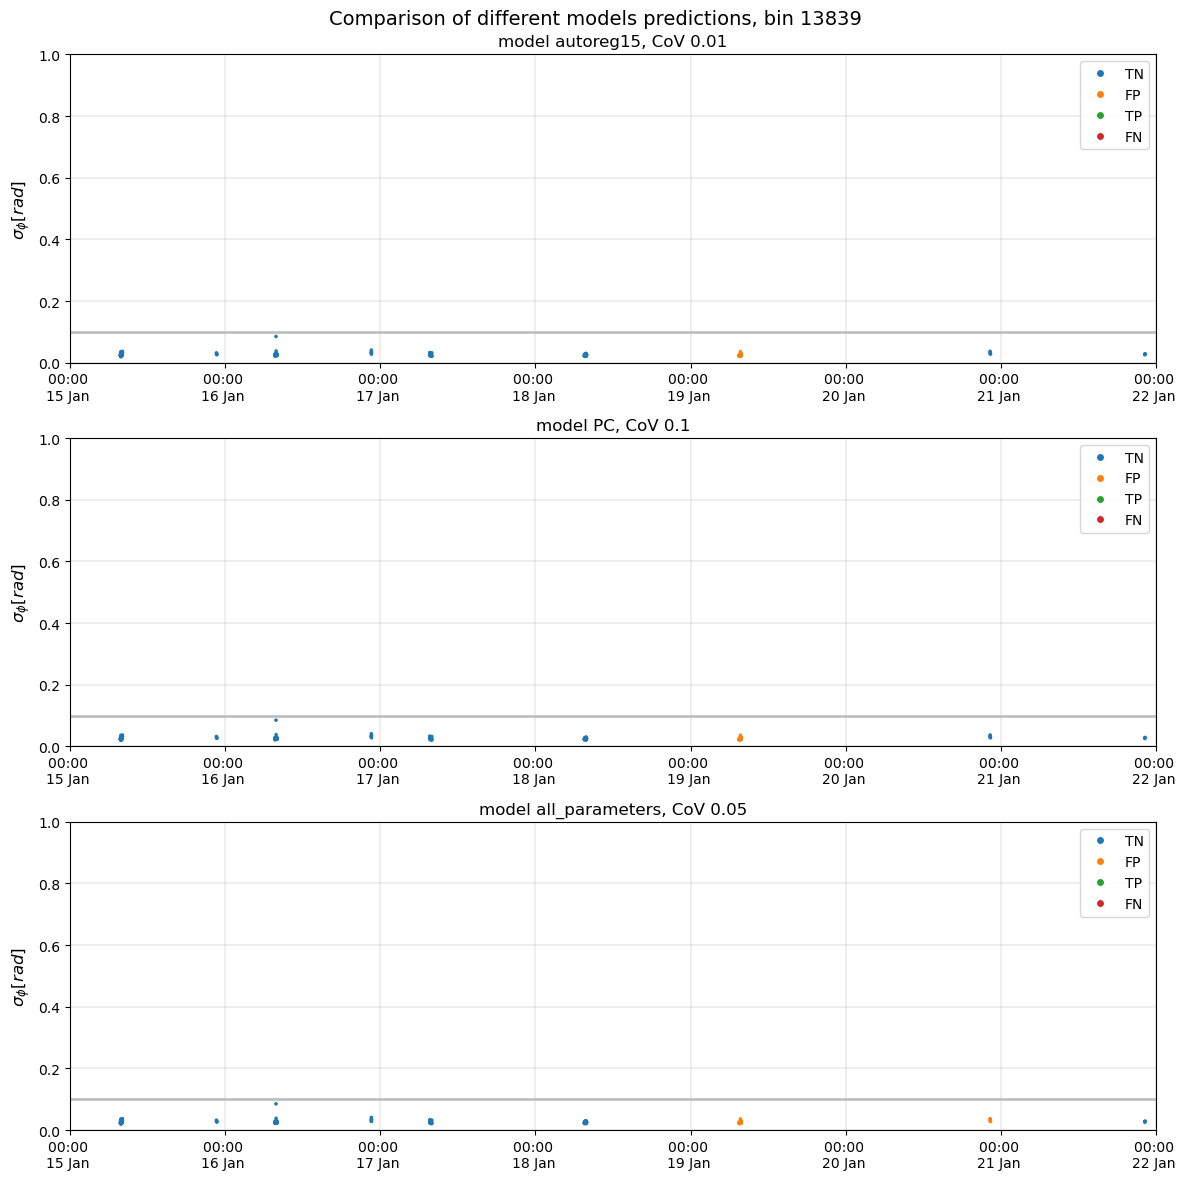

In [27]:
# SETTINGS
start_time = '2019-01-01 00:00:00'   # start time for plot
weeks = 2                            # how many weeks to plot

plt.rcParams["figure.figsize"] = (12,12)
n = len(visual2_models)

for i in range(0, weeks+1):  
    fig, ax = plt.subplots(n,1)
    plt.setp(ax, xlim=(pd.Timestamp(start_time)+datetime.timedelta(days=i*7), pd.Timestamp(start_time)+datetime.timedelta(days=i*7+7)))
    plt.suptitle(f'Comparison of different models predictions, bin {bin_used}', fontsize=14)
    
    ix = 0
    for m, pred, true in l:
        ix = ix+1
        plt.subplot(n, 1, ix).set_title(f"model {m}, CoV {pred}", fontsize=12)
        scatter=plt.scatter(visual2_df[f"{m}_time"], visual2_df[f"{m}_test"], s=size_of_marker, c=visual2_df[f'e_cm_color_{m}'], cmap="tab10", vmin=1, vmax=10)
        add_text_plot(1)
        add_legend_classification()

    plt.subplots_adjust(left=0.1,
                    bottom=0.1,
                    right=0.9,
                    top=0.9,
                    wspace=0.4,
                    hspace=0.4)
    
    plt.tight_layout()
    #plt.savefig(f"img{ix}.png")
    plt.show()
    